In [25]:
# Cell 1 — Initialize SLM with Kunal's calibrated 759-nm LUT

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


from slmsuite.hardware.slms.meadowlark import Meadowlark


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

KUNAL_LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM"
    r"\LUT from Kunal - B grade SLM"
    r"\759nm_KS_global_20260811.lut"
)


# ------------------------------------------------------------
# Initialize SLM
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(KUNAL_LUT_PATH),
    wav_um=0.759,
    verbose=True,
)


print("\n=== SLM ready ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Bit depth  :", slm.bitdepth)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")
print("LUT        :", KUNAL_LUT_PATH)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM ready ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Bit depth  : 8
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um
LUT        : C:\Users\admin\Desktop\Projects\SLM\LUT from Kunal - B grade SLM\759nm_KS_global_20260811.lut


=== Blazed grating ===
Pitch                  : 256 pixels
Physical period        : 2048 um
Number of phase levels : 256
Phase min              : 0.0 rad
Phase max              : 6.258641614573416 rad


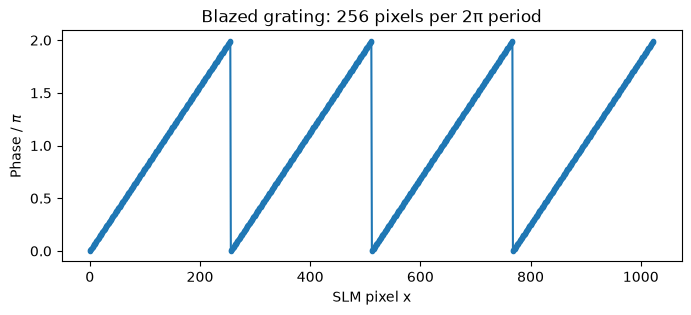


Blazed grating written to SLM.


In [24]:
# Cell 2 — Generate and display a blazed grating

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHANGE ONLY THIS NUMBER
# ============================================================

pitch_px = 256     # allowed: 2, 4, 6, ..., 32


# ============================================================
# Generate 0 -> 2π phase ramp
# ============================================================

ny, nx = slm.shape

x = np.arange(nx)

# One complete 0 -> 2π ramp every pitch_px pixels
phase_line = 2 * np.pi * (x % pitch_px) / pitch_px

# Repeat along y -> vertical stripes -> diffraction along x
phase_grating = np.tile(
    phase_line,
    (ny, 1)
)


# ============================================================
# Diagnostics
# ============================================================

print("=== Blazed grating ===")
print("Pitch                  :", pitch_px, "pixels")
print("Physical period        :", pitch_px * 8, "um")
print("Number of phase levels :", len(np.unique(phase_line)))
print("Phase min              :", phase_grating.min(), "rad")
print("Phase max              :", phase_grating.max(), "rad")


# ============================================================
# Plot 4 periods
# ============================================================

plt.figure(figsize=(8, 3))

plt.plot(
    x[:4 * pitch_px],
    phase_line[:4 * pitch_px] / np.pi,
    ".-",
)

plt.xlabel("SLM pixel x")
plt.ylabel(r"Phase / $\pi$")
plt.title(f"Blazed grating: {pitch_px} pixels per 2π period")

plt.show()


# ============================================================
# Send phase to SLM
#
# IMPORTANT:
# This is a float phase array in radians.
# slmsuite converts it using your calibrated LUT.
# ============================================================

slm.set_phase(
    phase_grating,
    settle=True,
)

print("\nBlazed grating written to SLM.")

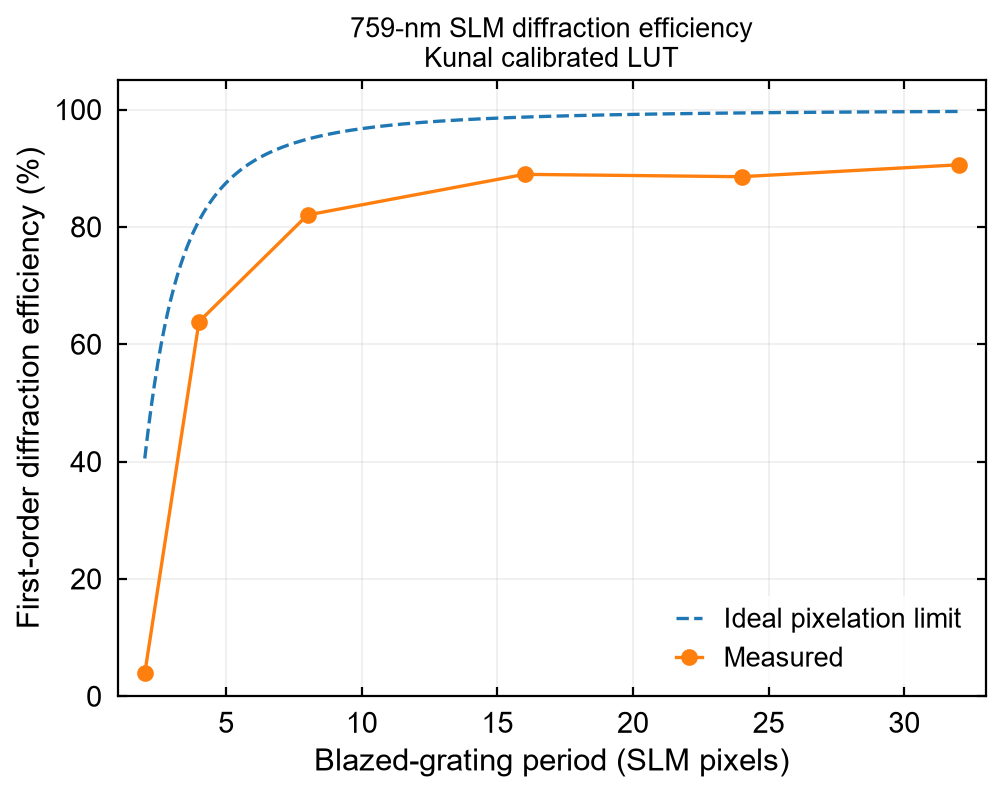

=== Measured diffraction efficiency ===
 2 pixels :  1.20/30.70 mW =   3.91 %
 4 pixels : 19.92/31.20 mW =  63.85 %
 8 pixels : 25.02/30.50 mW =  82.03 %
16 pixels : 27.40/30.80 mW =  88.96 %
24 pixels : 27.63/31.20 mW =  88.56 %
32 pixels : 27.90/30.80 mW =  90.58 %


In [26]:
# Plot measured blazed-grating diffraction efficiency

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Experimental data
# ------------------------------------------------------------

pitch_px = np.array([2, 4, 8, 16, 24, 32])

P_first_mW = np.array([
    1.20,
    19.92,
    25.02,
    27.40,
    27.63,
    27.90,
])

P_total_mW = np.array([
    30.7,
    31.2,
    30.5,
    30.8,
    31.2,
    30.8,
])


# ------------------------------------------------------------
# Measured diffraction efficiency
# ------------------------------------------------------------

efficiency = P_first_mW / P_total_mW
efficiency_percent = 100 * efficiency


# ------------------------------------------------------------
# Ideal efficiency from finite pixel sampling
#
# eta = [sin(pi/N)/(pi/N)]^2
# ------------------------------------------------------------

N_theory = np.linspace(2, 32, 500)

eta_theory = (
    np.sin(np.pi / N_theory)
    / (np.pi / N_theory)
)**2

eta_theory *= 100


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    N_theory,
    eta_theory,
    "--",
    label="Ideal pixelation limit",
)

plt.plot(
    pitch_px,
    efficiency_percent,
    "o-",
    label="Measured",
)

plt.xlabel("Blazed-grating period (SLM pixels)")
plt.ylabel("First-order diffraction efficiency (%)")

plt.title("759-nm SLM diffraction efficiency\nKunal calibrated LUT")

plt.xlim(1, 33)
plt.ylim(0, 105)

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# Print values
# ------------------------------------------------------------

print("=== Measured diffraction efficiency ===")

for N, p1, ptot, eta in zip(
    pitch_px,
    P_first_mW,
    P_total_mW,
    efficiency_percent,
):
    print(
        f"{N:2d} pixels : "
        f"{p1:5.2f}/{ptot:5.2f} mW "
        f"= {eta:6.2f} %"
    )

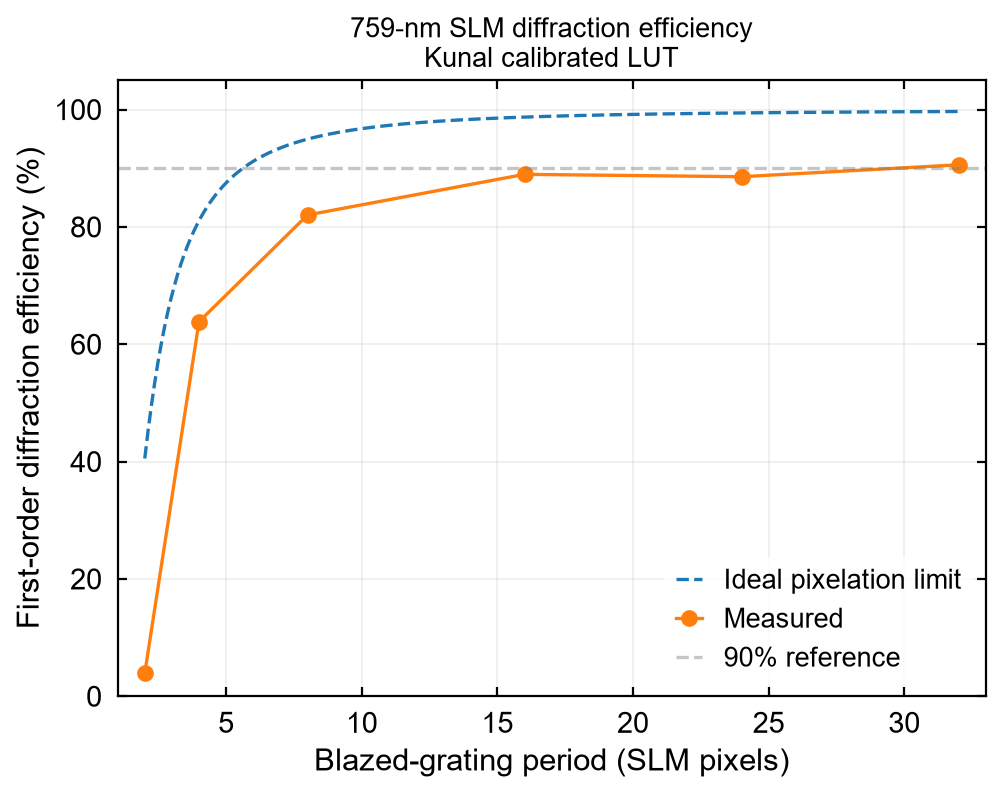

=== Measured diffraction efficiency ===
 2 pixels :  1.20/30.70 mW =   3.91 %
 4 pixels : 19.92/31.20 mW =  63.85 %
 8 pixels : 25.02/30.50 mW =  82.03 %
16 pixels : 27.40/30.80 mW =  88.96 %
24 pixels : 27.63/31.20 mW =  88.56 %
32 pixels : 27.90/30.80 mW =  90.58 %


: 

In [ ]:
# Plot measured blazed-grating diffraction efficiency

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Experimental data
# ------------------------------------------------------------

pitch_px = np.array([2, 4, 8, 16, 24, 32])

P_first_mW = np.array([
    1.20,
    19.92,
    25.02,
    27.40,
    27.63,
    27.90,
])

P_total_mW = np.array([
    30.7,
    31.2,
    30.5,
    30.8,
    31.2,
    30.8,
])


# ------------------------------------------------------------
# Measured diffraction efficiency
# ------------------------------------------------------------

efficiency = P_first_mW / P_total_mW
efficiency_percent = 100 * efficiency


# ------------------------------------------------------------
# Ideal efficiency from finite pixel sampling
#
# eta = [sin(pi/N)/(pi/N)]^2
# ------------------------------------------------------------

N_theory = np.linspace(2, 32, 500)

eta_theory = (
    np.sin(np.pi / N_theory)
    / (np.pi / N_theory)
)**2

eta_theory *= 100


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    N_theory,
    eta_theory,
    "--",
    label="Ideal pixelation limit",
)

plt.plot(
    pitch_px,
    efficiency_percent,
    "o-",
    label="Measured",
)

plt.axhline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="90% reference",
    color="gray",
    alpha=0.45
)

plt.xlabel("Blazed-grating period (SLM pixels)")
plt.ylabel("First-order diffraction efficiency (%)")

plt.title("759-nm SLM diffraction efficiency\nKunal calibrated LUT")

plt.xlim(1, 33)
plt.ylim(0, 105)

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ------------------------------------------------------------
# Print values
# ------------------------------------------------------------

print("=== Measured diffraction efficiency ===")

for N, p1, ptot, eta in zip(
    pitch_px,
    P_first_mW,
    P_total_mW,
    efficiency_percent,
):
    print(
        f"{N:2d} pixels : "
        f"{p1:5.2f}/{ptot:5.2f} mW "
        f"= {eta:6.2f} %"
    )